# **01. [Colorectal] Preparation and Data Analysis**

## **Introduction**
Preparation and Analysis of RHC-SP Colorectal Data for the Machine Learning Survival Study

## Environment Settings

In [ ]:
# download the file that contains the requirement management functions
!gdown 1563shEptjQS10FQbqjM-QsXot_cvHJBL --quiet
%run /content/bootstrap.py

# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# put here the your Drive's path to the project
LOCAL_PROJECT_PATH = "/content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida"

set_project(LOCAL_PROJECT_PATH)
setup()

Mounted at /content/drive
Projeto definido: /content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida

Grupos disponíveis:
1. data_analysis
2. ml
3. Criar novo grupo

Escolha (ex: 1,3): 1

Lendo dependências de data_analysis:
  - lifelines==0.30.3
  - matplotlib==3.10.0
  - numpy==2.0.2
  - pandas==2.2.2
  - plotly==5.24.1
  - scikit-learn==1.6.1
  - seaborn==0.13.2

 Instalando dependências necessárias:
 + lifelines==0.30.3

⚠️ Dependências instaladas.
Reiniciando o kernel automaticamente...


<IPython.core.display.Javascript object>

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import plotly.io as pio
pio.templates.default = 'simple_white'
colors = px.colors.sequential.ice

from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

## Functions

In [ ]:
def data_prep(df, topogrup):
    """
    Prepares the dataset for analysis, applying necessary filters and transformations.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset to be prepared.
    topogrup : list
        List with the topography group codes to be selected.

    Returns:
    --------
    pandas.DataFrame
        The dataset after the transformations.

    """

    df_aux = df.copy()

    # Colorectal Cancer Topography (C18, C19, C20) - Filter for specific cancer topographies
    df_aux = df_aux[df_aux.TOPOGRUP.isin(topogrup)]
    print(df_aux.shape)

    # Age - Filter for age greater than 19
    df_aux = df_aux[df_aux.IDADE > 19]

    # Residency - Filter for residents of SP
    df_aux = df_aux[df_aux.UFRESID == 'SP']

    # ECGRUP - Remove records with ECGRUP equal to 0, X or Y
    df_aux = df_aux[~df_aux.ECGRUP.isin(['0','X','Y'])]

    # ECGRUP Categorization - Categorize ECGRUP into 'Inicial' and 'Avançado'
    df_aux['ECGRUP_CAT'] = ['Inicial' if ec in ['I', 'II'] else 'Avançado' for ec in df_aux.ECGRUP]

    # ANODIAG - Filter for diagnosis year before 2020 (commented out)
    # df_aux = df_aux[df_aux.ANODIAG < 2020]

    # Microscopic Confirmation - Filter for records with microscopic confirmation (BASEDIAG == 3)
    df_aux = df_aux[df_aux.BASEDIAG == 3]

    # Morphology - Filter for morphology 81403
    print(df_aux.shape)
    print(df_aux.MORFO.value_counts(normalize=True).head(10))
    df_aux = df_aux[df_aux.MORFO == 81403]

    # TMO and TMOAPOS - Filter for patients who did not undergo TMO and TMOAPOS
    df_aux = df_aux[df_aux.TMO == 0] #TMO - Bone marrow transplantation
    # df_aux = df_aux[df_aux.TMOAPOS == 0] #TMOAPOS - Bone marrow transplantation after

    # Date Columns - Convert to datetime objects
    list_datas = ['DTCONSULT', 'DTDIAG', 'DTTRAT', 'DTULTINFO']

    for col_data in list_datas:
        df_aux[col_data] = pd.to_datetime(df_aux[col_data])

    # Time Calculations - Calculate time differences in days
    df_aux['CONSDIAG'] = (df_aux.DTDIAG - df_aux.DTCONSULT).dt.days #CONSDIAG - Time between consultation and diagnosis
    df_aux['DIAGTRAT'] = (df_aux.DTTRAT - df_aux.DTDIAG).dt.days #DIAGTRAT - Time between diagnosis and treatment
    df_aux['TRATCONS'] = (df_aux.DTTRAT - df_aux.DTCONSULT).dt.days #TRATCONS - Time between treatment and consultation
    df_aux['ULTIDIAG'] = (df_aux.DTULTINFO - df_aux.DTDIAG).dt.days #ULTIDIAG - Time between last information and diagnosis
    df_aux[['DIAGTRAT', 'TRATCONS']] = df_aux[['DIAGTRAT', 'TRATCONS']].fillna(-1) #Fill NaN values with -1

    # Time Categories - Create categorical variables for time differences
    df_aux['CONSDIAG_CAT'] = [0 if consdiag <= 30 else 1 if consdiag <= 60 else 2 for consdiag in df_aux.CONSDIAG]
    df_aux['TRATCONS_CAT'] = [3 if tratcons < 0 else 0 if tratcons <= 60 else 1 if tratcons <= 90 else 2 for tratcons in df_aux.TRATCONS]
    df_aux['DIAGTRAT_CAT'] = [3 if diagtrat < 0 else 0 if diagtrat <= 60 else 1 if diagtrat <= 90 else 2 for diagtrat in df_aux.DIAGTRAT]

    # Metastasis Presence - Create a column indicating the presence of metastasis
    df_aux['PRESENCA_META'] = 0
    df_aux.loc[df_aux.META01.notnull(), 'PRESENCA_META'] = 1

    # Recurrence Presence - Create a variable for presence of recurrence (0 = No, 1 = Yes)
    df_aux['PRESENCA_REC'] = [0 if rec == 1 else 1 for rec in df_aux.RECNENHUM]
    df_aux.loc[(df_aux.PRESENCA_REC == 0) & (df_aux.DTRECIDIVA.notnull()), 'PRESENCA_REC'] = 1

    # DRS - Extract DRS number
    DRS_expand = df_aux.DRS.str.split(' ', expand=True)
    df_aux['DRS'] = DRS_expand[1]

    # DRS_INST - Extract DRS_INST number
    DRS_expand = df_aux.DRS_INST.str.split(' ', expand=True)
    df_aux['DRS_INST'] = DRS_expand[1]

    # Outcome Variables - Create outcome variables (overall survival, cancer-specific survival, and survival at 1, 3, and 5 years)
    df_aux['obito_geral'] = 0
    df_aux['obito_cancer'] = 0

    df_aux['sobrevida_ano1'] = 0
    df_aux['sobrevida_ano3'] = 0
    df_aux['sobrevida_ano5'] = 0

    df_aux.loc[df_aux.ULTINFO > 2, 'obito_geral'] = 1
    df_aux.loc[df_aux.ULTINFO == 3, 'obito_cancer'] = 1

    df_aux.loc[df_aux.ULTIDIAG > 365.25, 'sobrevida_ano1'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 3*365.25, 'sobrevida_ano3'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 5*365.25, 'sobrevida_ano5'] = 1

    # Drop Unused Columns - Remove columns that will not be used in the analysis
    col = df_aux.columns
    drop_cols = ['UFNASC', 'UFRESID', 'CIDADE', 'DTCONSULT', 'CLINICA', 'DTDIAG',
                 'BASEDIAG', 'TOPOGRUP', 'DESCTOPO', 'DESCMORFO', 'T', 'N', 'M',
                 'PT', 'PN', 'PM', 'S', 'G', 'PSA', 'GLEASON', 'LOCALTNM',
                 'IDMITOTIC', 'OUTRACLA', 'META01', 'META02', 'META03', 'META04',
                 'DTTRAT', 'NAOTRAT', 'TRATAMENTO', 'TRATHOSP', 'TRATFANTES',
                 'TRATFAPOS', 'NENHUMANT', 'CIRURANT', 'RADIOANT', 'QUIMIOANT',
                 'HORMOANT', 'TMOANT', 'IMUNOANT', 'OUTROANT', 'DTULTINFO',
                 'CICI', 'CICIGRUP', 'CICISUBGRU', 'FAIXAETAR', 'LATERALI',
                 'INSTORIG', 'PERDASEG', 'ERRO', 'DTRECIDIVA', 'RECNENHUM',
                 'RECLOCAL', 'RECREGIO', 'RECDIST', 'REC01', 'REC02', 'REC03',
                 'REC04', 'CIDO', 'DSCCIDO', 'HABILIT', 'HABIT11', 'HABILIT1',
                 'CIDADEH', 'CIDADE_INS', 'TMO', 'TMOAPOS', 'MORFO']

    col = col.drop(drop_cols)

    return df_aux[col]

# **Data Preparation**

Step responsible for organizing, cleaning, and transforming raw data into a format suitable for analysis and modeling.

In [ ]:
# Database - Set/2024
!gdown 1_CGn_150mpmfxwsyVyB5LTeqeAVgJKhB --quiet

In [ ]:
# Load Data and Display Information
df = pd.read_csv('pacigeral_set24.csv')  # Load the CSV file into a Pandas DataFrame

print(df.shape)  # Print the dimensions of the DataFrame (rows, columns)
df.head(3)  # Display the first 3 rows of the DataFrame

/tmp/ipykernel_9562/3015456548.py:2: DtypeWarning: Columns (24,25,26,33,37,79,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('pacigeral_set24.csv')  # Load the CSV file into a Pandas DataFrame


(1233793, 105)


,INSTITU,ESCOLARI,IDADE,SEXO,UFNASC,UFRESID,IBGE,CIDADE,CATEATEND,DTCONSULT,...,CIDO,DSCCIDO,HABILIT,HABIT11,HABILIT1,HABILIT2,CIDADEH,DRS_INST,RRAS_INST,CIDADE_INS
0,14,4,49,2,SC,SC,4209409,LAGUNA,9,2011-03-23,...,81603.0,COLANGIOCARCINOMA,14,Inativo,6,5,São Paulo,DRS 01 Grande Sao Paulo,RRAS 06,SAO PAULO
1,8672,9,54,1,SP,SP,3550308,SAO PAULO,9,2006-05-30,...,80903.0,CARCINOMA BASOCELULAR SOE,7,CACON com Serviço de Oncologia Pediátrica,3,2,São Paulo,DRS 01 Grande Sao Paulo,RRAS 06,SAO PAULO
2,19100,9,77,1,SP,SP,3504503,AVARE,9,2003-12-14,...,82113.0,ADENOCARCINOMA TUBULAR,14,Inativo,6,5,Avaré,DRS 06 Bauru,RRAS 09,AVARE


In [ ]:
# Prepare Data for Colorectal Cancer Analysis
df_colo = data_prep(df, ['C18', 'C19', 'C20']) # Prepare the data, filtering for colorectal cancer (ICD-10 code 'C18', 'C19', 'C20')

print(df_colo.shape) # Print the shape (rows, columns) of the filtered DataFrame
df_colo.head(3) # Display the first 3 rows of the filtered DataFrame

(90625, 105)
(76929, 106)
MORFO
81403    0.583109
82113    0.293335
84803    0.041467
82633    0.017432
82623    0.010308
80103    0.007630
84903    0.006889
84813    0.006318
82463    0.006071
80203    0.004888
Name: proportion, dtype: float64
(44857, 48)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5
15,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,0,1,0,0,0,0,1,0,0
20,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,1,0,1,1,1
49,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,0,1,0,0,1,1,1


In [ ]:
# Final Columns
df_colo.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5'],
      dtype='object')

**Morphologies ending in 2**

In [ ]:
df_sem_insitu = df_colo[df_colo.ECGRUP_CAT != 'In Situ']

df_sem_insitu[df_sem_insitu['MORFO'].astype(str).str.endswith('2')].shape

In [ ]:
df_sem_insitu[df_sem_insitu['MORFO'].astype(str).str.endswith('2')].index

In [ ]:
df_morfo_final2 = df.loc[df_sem_insitu[df_sem_insitu['MORFO'].astype(str).str.endswith('2')].index]
df_morfo_final2.shape

In [ ]:
df_morfo_final2.to_csv('colorretal_morfo_final2.csv', index=False)

## **KNNImputer**

Missing data imputation technique that uses the k-nearest neighbors to estimate and fill in missing values based on similarity among observations.

In [ ]:
# df_colo.ESCOLARI.value_counts(normalize=True).sort_index()

,proportion
ESCOLARI,
1,0.037229
2,0.257463
3,0.182759
4,0.140491
5,0.076488
9,0.305571


In [ ]:
# escolari = df_colo[df_colo.ESCOLARI != 9]
# escolari.ESCOLARI.value_counts().sort_index()

,count
ESCOLARI,
1,1670
2,11549
3,8198
4,6302
5,3431


In [ ]:
# from sklearn.impute import KNNImputer
# from sklearn.preprocessing import MinMaxScaler

# # Input da ESCOLARI
# cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'CATEATEND']

# df_esc = df_colo[cols_input].copy()
# df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
# df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
# df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
# df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
# df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

# X = df_esc.values
# mms = MinMaxScaler()
# X[:, 1:] = mms.fit_transform(X[:, 1:])

# imputer = KNNImputer(n_neighbors=1, weights='distance')
# df_colo['ESCOLARI_PREENCH'] = imputer.fit_transform(X)[:,0].round()

# df_colo.ESCOLARI_PREENCH.value_counts().sort_index()

,count
ESCOLARI_PREENCH,
1.0,2454
2.0,16921
3.0,10503
4.0,8320
5.0,6659


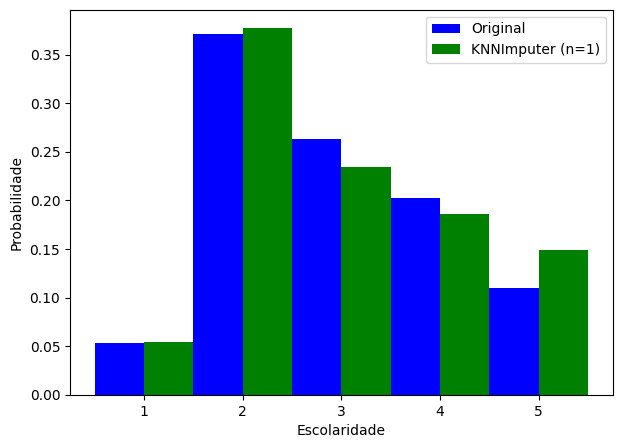

In [ ]:
# import matplotlib.pyplot as plt

# x = np.sort(escolari.ESCOLARI.unique())
# inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
# knn1 = df_colo.ESCOLARI_PREENCH.value_counts().sort_index().values/df_colo.shape[0]

# plt.figure(figsize=(7, 5))
# plt.bar(x - 0.25, inic, color='b', width=0.5, label='Original')
# plt.bar(x + 0.25, knn1, color='g', width=0.5, label='KNNImputer (n=1)')
# plt.ylabel("Probabilidade")
# plt.xlabel("Escolaridade")
# plt.legend()

# plt.show()

In [ ]:
# from scipy.stats import ks_2samp

# # Realize o teste de Kolmogorov-Smirnov
# statistic, p_value = ks_2samp(escolari.ESCOLARI, df_colo.ESCOLARI_PREENCH)

# # Exiba o resultado do teste
# print('Estatística de teste:', statistic)
# print('p-value:', p_value)

# # Verifique se a diferença entre as distribuições é significativa
# alpha = 0.05
# if p_value > alpha:
#     print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
# else:
#     print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

Estatística de teste: 0.03830505507585702
p-value: 7.126636031503276e-24

Rejeitamos a hipótese nula (as distribuições são diferentes)


## **Information**

In [ ]:
df_colo.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5'],
      dtype='object')

In [ ]:
# Calculate and Adjust Survival Time in Months
df_colo['meses_diag'] = np.ceil(df_colo['ULTIDIAG']/30).astype(int)  # Calculate survival time in months, rounding up

df_colo.loc[df_colo.meses_diag == 0, 'meses_diag'] = 1  # Ensure no survival time is zero (set to 1 month)
df_colo.loc[df_colo.meses_diag > 60, ['meses_diag', 'obito_geral']] = [61, 0]  # Cap survival time at 61 months and set obito_geral to 0 for those exceeding the cap.

df_colo.meses_diag.value_counts().sort_index().tail()  # Display the value counts for the last few survival times (for checking)

,count
meses_diag,
57,189
58,183
59,210
60,207
61,12180


**General Columns**

In [ ]:
df_colo.obito_cancer.value_counts().sort_index()

,count
obito_cancer,
0,26259
1,18598


**Outputs**

In [ ]:
ano = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano5 == 0))]
print(ano.shape)
ano.sobrevida_ano5.value_counts().sort_index()

(33957, 48)


,count
sobrevida_ano5,
0,21962
1,11995


**Saving the database into a csv file**

In [ ]:
# Saving database
df_colo.to_csv('colorretal.csv', index=False)

# **Data Exploration**

Initial analysis process to understand the structure, distribution, and patterns within the data.

## **Data**

In [ ]:
# Colorectal
!gdown 1yzI52UDZyac0QGWmKL5Mai1JOqWUTeMQ --quiet

In [ ]:
df = pd.read_csv('colorretal.csv')
print(df.shape)
df.head(3)

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
df.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag'],
      dtype='object')

In [ ]:
x = np.sort(df.ANODIAG.unique())
y = df.ANODIAG.value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Bar(x=x,
                     y=y,
                     name='Masculino',
                     text=y,
                     marker_color=colors[5]
              ))

fig.update_layout(title_text='Pacientes por ano do diagnóstico',
                  yaxis_title='Número de Pacientes',
                  xaxis_title='Ano do Diagnóstico')

fig.update_xaxes(tickmode='linear', tick0=2000, dtick=1, tickangle=-45)
fig.update_traces(texttemplate='%{text}')

fig.show()

In [ ]:
masc = df[df.SEXO == 1]
fem = df[df.SEXO == 2]

mascx = np.sort(masc.ANODIAG.unique())
mascy = masc.ANODIAG.value_counts().sort_index()

femx = np.sort(fem.ANODIAG.unique())
femy = fem.ANODIAG.value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Bar(x = mascx,
                     y = mascy,
                     name = 'Masculino',
                     text = mascy,
                     marker_color=colors[3]
              ))

fig.add_trace(go.Bar(x = femx,
                     y = femy,
                     name = 'Feminino',
                     text = femy,
                     marker_color=colors[6]
              ))

fig.update_layout(barmode='group', title_text='Pacientes por ano do diagnóstico',
                  yaxis_title = 'Número de Pacientes', xaxis_title='Ano do Diagnóstico',
                  legend=dict(orientation="v",  # horizontal orientation
                              yanchor="bottom", # sets the vertical anchor point to the bottom.
                              y=1,  # positioning the legend above the plot
                              xanchor="center",  # sets the horizontal anchor point to the center.
                              x=0.93  # center the legend
    ))

fig.update_xaxes(tickmode='linear', tick0=2000, dtick=1, tickangle=-45)
fig.update_traces(texttemplate='%{text}')

fig.show()

In [ ]:
anodiag_ec = df.groupby(by=['ANODIAG'], sort=True)['ECGRUP'].value_counts(normalize=True).sort_index()

ano = np.sort(df.ANODIAG.unique())
y1 = anodiag_ec.unstack()['I']
y2 = anodiag_ec.unstack()['II']
y3 = anodiag_ec.unstack()['III']
y4 = anodiag_ec.unstack()['IV']

fig = go.Figure()

fig.add_trace(go.Bar(x=ano, y=y1, name='EC I', marker_color=colors[8]))
fig.add_trace(go.Bar(x=ano, y=y2, name='EC II', marker_color=colors[6]))
fig.add_trace(go.Bar(x=ano, y=y3, name='EC III', marker_color=colors[4]))
fig.add_trace(go.Bar(x=ano, y=y4, name='EC IV', marker_color=colors[2]))

fig.update_layout(barmode='stack', yaxis_title='% de pacientes',
                  xaxis_title='Ano',
                  title='Porcentagem de pacientes por estadimento clínico ao longo dos anos')
fig.update_xaxes(tickmode='linear', tick0=2000, dtick=1, tickangle=-45)

fig.show()

In [ ]:
anodiag_ec = masc.groupby(by=['ANODIAG'], sort=True)['ECGRUP'].value_counts(normalize=True).sort_index()

ano = np.sort(df.ANODIAG.unique())
y1 = anodiag_ec.unstack()['I']
y2 = anodiag_ec.unstack()['II']
y3 = anodiag_ec.unstack()['III']
y4 = anodiag_ec.unstack()['IV']

fig = go.Figure()

fig.add_trace(go.Bar(x=ano, y=y1, name='EC I', marker_color=colors[8]))
fig.add_trace(go.Bar(x=ano, y=y2, name='EC II', marker_color=colors[6]))
fig.add_trace(go.Bar(x=ano, y=y3, name='EC III', marker_color=colors[4]))
fig.add_trace(go.Bar(x=ano, y=y4, name='EC IV', marker_color=colors[2]))

fig.update_layout(barmode='stack', yaxis_title='% de pacientes',
                  xaxis_title='Ano',
                  title='Porcentagem de Homens por estadimento clínico ao longo dos anos')
fig.update_xaxes(tickmode='linear', tick0=2000, dtick=1, tickangle=-45)

fig.show()

In [ ]:
anodiag_ec = fem.groupby(by=['ANODIAG'], sort=True)['ECGRUP'].value_counts(normalize=True).sort_index()

ano = np.sort(df.ANODIAG.unique())
y1 = anodiag_ec.unstack()['I']
y2 = anodiag_ec.unstack()['II']
y3 = anodiag_ec.unstack()['III']
y4 = anodiag_ec.unstack()['IV']

fig = go.Figure()

fig.add_trace(go.Bar(x=ano, y=y1, name='EC I', marker_color=colors[8]))
fig.add_trace(go.Bar(x=ano, y=y2, name='EC II', marker_color=colors[6]))
fig.add_trace(go.Bar(x=ano, y=y3, name='EC III', marker_color=colors[4]))
fig.add_trace(go.Bar(x=ano, y=y4, name='EC IV', marker_color=colors[2]))

fig.update_layout(barmode='stack', yaxis_title='% de pacientes',
                  xaxis_title='Ano',
                  title='Porcentagem de Mulheres por estadimento clínico ao longo dos anos')
fig.update_xaxes(tickmode='linear', tick0=2000, dtick=1, tickangle=-45)

fig.show()

In [ ]:
x = np.sort(df.IDADE.unique())
y = df.IDADE.value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Bar(x=x,
                     y=y,
                     name='Masculino',
                    #  text=y,
                     marker_color=colors[5]
              ))

fig.update_layout(title_text='Pacientes por idade',
                  yaxis_title='Número de Pacientes',
                  xaxis_title='Idade')

fig.show()

In [ ]:
masc = df[df.SEXO == 1]
fem = df[df.SEXO == 2]

mascx = np.sort(masc.ESCOLARI.unique())
mascy = masc.ESCOLARI.value_counts().sort_index()

femx = np.sort(fem.ESCOLARI.unique())
femy = fem.ESCOLARI.value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Bar(x = mascx,
                     y = (mascy/masc.shape[0])*100,
                     name = 'Masculino',
                     text = (mascy/masc.shape[0])*100,
                     marker_color=colors[3]
              ))

fig.add_trace(go.Bar(x = femx,
                     y = (femy/fem.shape[0])*100,
                     name = 'Feminino',
                     text = (femy/fem.shape[0])*100,
                     marker_color=colors[6]
              ))

fig.update_layout(barmode='group', title_text='Pacientes por escolaridade',
                  yaxis_title = '% de Pacientes', xaxis_title='Escolaridade',
                  legend=dict(orientation="v",  # horizontal orientation
                              yanchor="bottom", # sets the vertical anchor point to the bottom.
                              y=1,  # posição da legenda acima do gráfico
                              xanchor="center",  # positioning the legend above the plot
                              x=0.93  # center the legend
    ))

fig.update_xaxes(
    ticktext=['Analfabeto', 'Ens. Fund. Incompleto', 'Ens. Fund. Completo',
              'Ens. Médio', 'Superior', 'Ignorada'],
    tickvals=[1, 2, 3, 4, 5, 9],
    tickangle=-25
)

fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

fig.show()

In [ ]:
ulti1 = df[df.ULTINFO == 1]
ulti2 = df[df.ULTINFO == 2]
ulti3 = df[df.ULTINFO == 3]
ulti4 = df[df.ULTINFO == 4]

ulti1x = np.sort(ulti1.ESCOLARI.unique())
ulti1y = ulti1.ESCOLARI.value_counts().sort_index()

ulti2x = np.sort(ulti2.ESCOLARI.unique())
ulti2y = ulti2.ESCOLARI.value_counts().sort_index()

ulti3x = np.sort(ulti3.ESCOLARI.unique())
ulti3y = ulti3.ESCOLARI.value_counts().sort_index()

ulti4x = np.sort(ulti4.ESCOLARI.unique())
ulti4y = ulti4.ESCOLARI.value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Bar(x = ulti1x,
                     y = (ulti1y/ulti1.shape[0])*100,
                     name = 'Vivo com câncer',
                     text = (ulti1y/ulti1.shape[0])*100,
                     marker_color=colors[2]
              ))

fig.add_trace(go.Bar(x = ulti2x,
                     y = (ulti2y/ulti2.shape[0])*100,
                     name = 'Vivo SOE',
                     text = (ulti2y/ulti2.shape[0])*100,
                     marker_color=colors[4]
              ))

fig.add_trace(go.Bar(x = ulti3x,
                     y = (ulti3y/ulti3.shape[0])*100,
                     name = 'Óbito por câncer',
                     text = (ulti3y/ulti3.shape[0])*100,
                     marker_color=colors[6]
              ))

fig.add_trace(go.Bar(x = ulti4x,
                     y = (ulti4y/ulti4.shape[0])*100,
                     name = 'Óbito outras causas, SOE',
                     text = (ulti4y/ulti4.shape[0])*100,
                     marker_color=colors[8]
              ))

fig.update_layout(barmode = 'group', title_text='Última informação dos pacientes para cada escolaridade',
                  yaxis_title = '% de Pacientes', xaxis_title = 'Escolaridade',
                  legend=dict(orientation="v",  # orientação horizontal
                              yanchor="bottom", # ancoragem no fundo
                              y=0.85,  # posição da legenda acima do gráfico
                              xanchor="center",  # ancoragem no centro
                              x=0.75  # centralizar a legenda
    ))
fig.update_xaxes(
    ticktext=['Analfabeto', 'Ens. Fund. Incompleto', 'Ens. Fund. Completo',
              'Ens. Médio', 'Superior', 'Ignorada'],
    tickvals=[1, 2, 3, 4, 5, 9],
    tickangle=-25
)

fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

fig.show()

In [ ]:
ob0 = df[df.obito_geral == 0]
ob1 = df[df.obito_geral == 1]

ob0x = np.sort(ob0.ESCOLARI.unique())
ob0y = ob0.ESCOLARI.value_counts().sort_index()

ob1x = np.sort(ob1.ESCOLARI.unique())
ob1y = ob1.ESCOLARI.value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Bar(x = ob0x,
                     y = (ob0y/ob0.shape[0])*100,
                     name = 'Vivo',
                     text = (ob0y/ob0.shape[0])*100,
                     marker_color=colors[3]
              ))

fig.add_trace(go.Bar(x = ob1x,
                     y = (ob1y/ob1.shape[0])*100,
                     name = 'Óbito',
                     text = (ob1y/ob1.shape[0])*100,
                     marker_color=colors[6]
              ))

fig.update_layout(barmode = 'group', title_text='Óbito por qualquer razão dos pacientes para cada escolaridade',
                  yaxis_title = '% de Pacientes', xaxis_title = 'Escolaridade',
                  legend=dict(orientation="v",  # horizontal orientation
                              yanchor="bottom", # sets the vertical anchor point to the bottom.
                              y=0.75,  # positioning the legend above the plot
                              xanchor="center",  # sets the horizontal anchor point to the center.
                              x=0.85  # center the legend
    ))
fig.update_xaxes(
    ticktext=['Analfabeto', 'Ens. Fund. Incompleto', 'Ens. Fund. Completo',
              'Ens. Médio', 'Superior', 'Ignorada'],
    tickvals=[1, 2, 3, 4, 5, 9],
    tickangle=-25
)

fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

fig.show()

In [ ]:
mascx = np.sort(masc.ULTINFO.unique())
mascy = masc.ULTINFO.value_counts().sort_index()

femx = np.sort(fem.ULTINFO.unique())
femy = fem.ULTINFO.value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Bar(x = mascx,
                     y = (mascy/masc.shape[0])*100,
                     name = 'Masculino',
                     text=(mascy/masc.shape[0])*100,
                     marker_color=colors[3]
              ))

fig.add_trace(go.Bar(x = femx,
                     y = (femy/fem.shape[0])*100,
                     name = 'Feminino',
                     text=(femy/fem.shape[0])*100,
                     marker_color=colors[6]
              ))

fig.update_xaxes(
    ticktext=['Vivo, com câncer', 'Vivo, SOE',
              'Óbito por câncer', 'Óbito outras causa, SOE'],
    tickvals=[1, 2, 3, 4],
)

fig.update_layout(barmode = 'group', title_text='Última informação dos pacientes',
                  yaxis_title = '% de Pacientes', xaxis_title = 'Última informação',
                  legend=dict(orientation="v",  # horizontal orientation
                              yanchor="bottom", # sets the vertical anchor point to the bottom.
                              y=1,  # positioning the legend above the plot
                              xanchor="center",  # sets the horizontal anchor point to the center.
                              x=0.93  # center the legend
    ))

fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

fig.show()

### **Cases and Deaths**

In [ ]:
# Columns
df.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag'],
      dtype='object')

In [ ]:
# --- Calculate total cases per diagnosis year ---
# Extract 'ANODIAG' column, count occurrences per year, and sort by year index
ano = df.ANODIAG.value_counts().sort_index()

# Convert Series to DataFrame for structural consistency
ano = pd.DataFrame(ano)

# --- Add death counts to the DataFrame ---
# Calculate total deaths by grouping by diagnosis year and summing 'obito_geral' (death indicator)
# The index alignment ensures matching with existing 'ano' index
ano['obito'] = df.groupby('ANODIAG').obito_geral.sum()

In [ ]:
# Import Plotly's graph objects module for advanced visualizations
import plotly.graph_objects as go

# Initialize a blank Figure object
fig = go.Figure()

# Background layer: Total cases (with reduced opacity for visibility)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['count'],                  # Total case counts on y-axis
    name="Total cases",              # Legend label
    marker_color='blue',             # Base color for total cases
    opacity=0.6                      # Partial transparency for overlay effect
))

# Foreground layer: Deaths (more opaque for emphasis)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['obito'],                  # Death counts on y-axis
    name="Deaths",                   # Legend label
    marker_color='red',              # Highlight color for deaths
    opacity=0.8                      # Higher opacity for visual prominence
))

# Critical layout configuration for proper overlay
fig.update_layout(
    barmode='overlay',               # Overlap bars instead of stacking
    title_text="Colorectal Cancer",  # Chart title
    xaxis_tickangle=-45,             # Rotate x-axis labels for readability
    xaxis=dict(
        tickmode='linear',          # Show every year
        tick0=2000,                 # First tick at year 2000
        dtick=1,                    # Tick interval = 1 year
        title_text="Year of diagnosis"  # X-axis label (fixed typo)
    ),
    yaxis=dict(
        title_text="Number of patients"  # Y-axis label
    )
)

# Display the interactive visualization
fig.show()

In [ ]:
# --- Calculate total cases per diagnosis year ---
# Extract 'ANODIAG' column, count occurrences per year, and sort by year index
ano = df.ANODIAG.value_counts().sort_index()

# Convert Series to DataFrame for structural consistency
ano = pd.DataFrame(ano)

# --- Add death y cancer counts to the DataFrame ---
# Calculate total deaths by cancer by grouping by diagnosis year and summing 'obito_cancer' (death indicator)
# The index alignment ensures matching with existing 'ano' index
ano['obito_cancer'] = df.groupby('ANODIAG').obito_cancer.sum()
ano

,count,obito_cancer
ANODIAG,,
2000,819,463
2001,804,447
2002,1051,575
2003,1172,641
2004,1378,725
2005,1547,829
2006,1349,687
2007,1316,665
2008,1580,765


In [ ]:
# Import Plotly's graph objects module for advanced visualizations
import plotly.graph_objects as go

# Initialize a blank Figure object
fig = go.Figure()

# Background layer: Total cases (with reduced opacity for visibility)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['count'],                  # Total case counts on y-axis
    name="Total cases",              # Legend label
    marker_color='blue',             # Base color for total cases
    opacity=0.6                      # Partial transparency for overlay effect
))

# Foreground layer: Deaths (more opaque for emphasis)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['obito_cancer'],           # Death counts on y-axis
    name="Deaths by cancer",         # Legend label
    marker_color='red',              # Highlight color for deaths
    opacity=0.8                      # Higher opacity for visual prominence
))

# Critical layout configuration for proper overlay
fig.update_layout(
    barmode='overlay',               # Overlap bars instead of stacking
    title_text="Colorectal Cancer",    # Chart title
    xaxis_tickangle=-45,             # Rotate x-axis labels for readability
    xaxis=dict(
        tickmode='linear',           # Show every year
        tick0=2000,                  # First tick at year 2000
        dtick=1,                     # Tick interval = 1 year
        title_text="Year of diagnosis"  # X-axis label (fixed typo)
    ),
    yaxis=dict(
        title_text="Number of patients"  # Y-axis label
    )
)

# Display the interactive visualization
fig.show()

## **Kaplan-Meier Curves**

**ECGRUP**

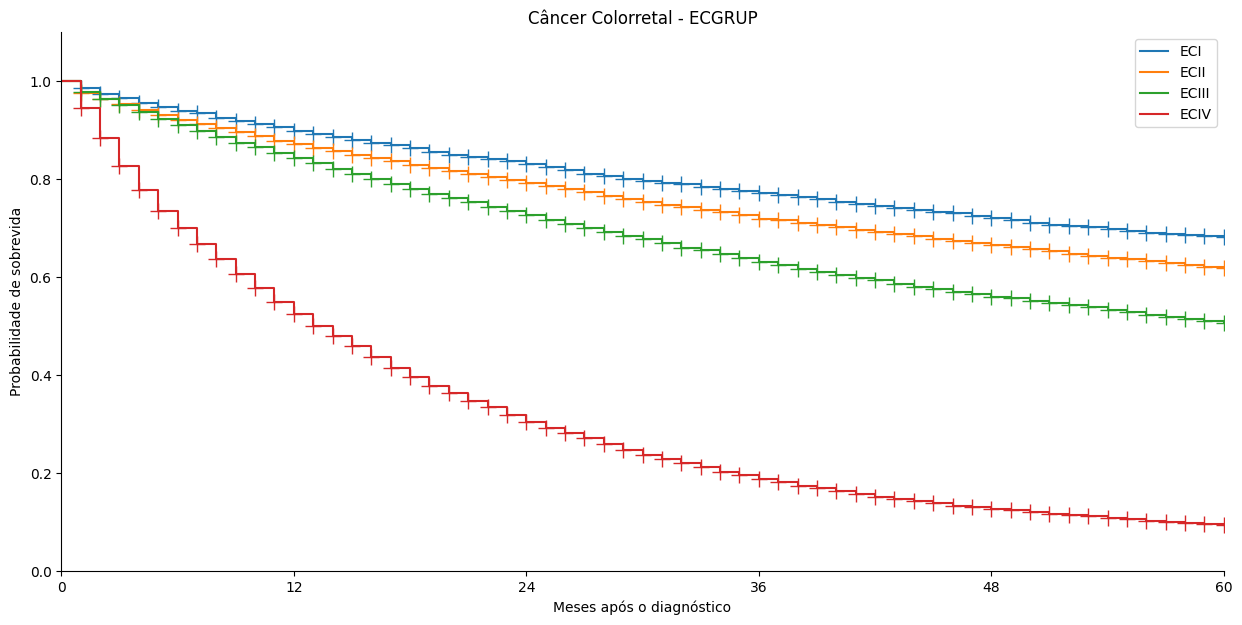

In [ ]:
data = df

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Câncer Colorretal - ECGRUP'

fig = plt.figure(figsize=(15, 7))
ax = plt.subplot(111)

group1 = (data.ECGRUP == 'I')
label1 = 'ECI'
kmf1 = KaplanMeierFitter()
T1=T[group1]
E1=E[group1]

group2 = (data.ECGRUP == 'II')
label2 = 'ECII'
kmf2 = KaplanMeierFitter()
T2=T[group2]
E2=E[group2]

group3 = (data.ECGRUP == 'III')
label3 = 'ECIII'
kmf3 = KaplanMeierFitter()
T3=T[group3]
E3=E[group3]

group4 = (data.ECGRUP == 'IV')
label4 = 'ECIV'
kmf4 = KaplanMeierFitter()
T4=T[group4]
E4=E[group4]

ax = kmf1.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf2.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf3.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf4.fit(T4, E4, label=label4).plot(ax=ax, ci_show=False, show_censors=True)

ax.set_title(title)
ax.set_xlabel('Meses após o diagnóstico')
ax.set_ylabel('Probabilidade de sobrevida')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 60]);

# plt.savefig('colorretal.svg')

**Topographies**

In [ ]:
df.TOPO.value_counts().sort_index()

,count
TOPO,
C180,1371
C181,81
C182,3547
C183,379
C184,1616
C185,327
C186,1996
C187,6638
C188,297


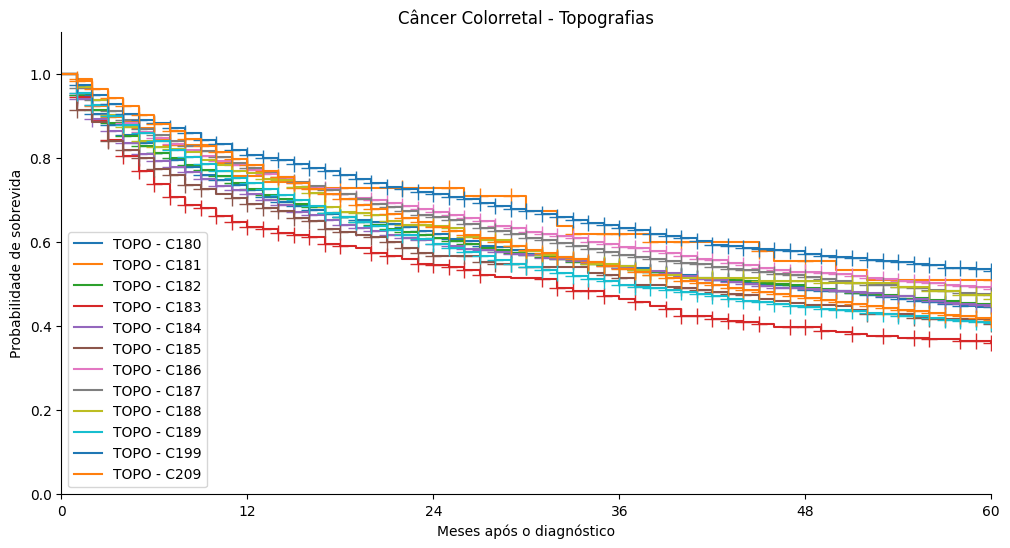

In [ ]:
topos = np.sort(df.TOPO.unique())

E = (df.obito_geral == 1)
T = df.meses_diag
title = 'Câncer Colorretal - Topografias'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

for topo in topos:
    group = (df.TOPO == f'{topo}')
    label = f'TOPO - {topo}'

    T1=T[group]
    E1=E[group]

    ax = kmf.fit(T1, E1, label=f"{label}").plot(ax=ax, ci_show=False,
                                                show_censors=True)

ax.set_title(title)
ax.set_xlabel('Meses após o diagnóstico')
ax.set_ylabel('Probabilidade de sobrevida')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 60])
plt.show()

**EC and Habilit2**

In [ ]:
df.ECGRUP.value_counts().sort_index()

,count
ECGRUP,
I,5378
II,12400
III,14394
IV,12685


In [ ]:
df_habilit = df[df.HABILIT2.isin([1, 2, 3])]
print(df_habilit.shape)
df_habilit.HABILIT2.value_counts().sort_index()

(41749, 49)


,count
HABILIT2,
1,19970
2,21482
3,297


In [ ]:
df_habilit.ECGRUP.value_counts().sort_index()

,count
ECGRUP,
I,4898
II,11456
III,13431
IV,11964


In [ ]:
df_ec1 = df_habilit[df_habilit.ECGRUP == 'I']
df_ec2 = df_habilit[df_habilit.ECGRUP == 'II']
df_ec3 = df_habilit[df_habilit.ECGRUP == 'III']
df_ec4 = df_habilit[df_habilit.ECGRUP == 'IV']

df_ec1.shape, df_ec2.shape, df_ec3.shape, df_ec4.shape

((4898, 49), (11456, 49), (13431, 49), (11964, 49))

log-rank p-value:
    CACON com UNACON = 3.838e-19
    CACON com Hosp. Geral = 0.007461



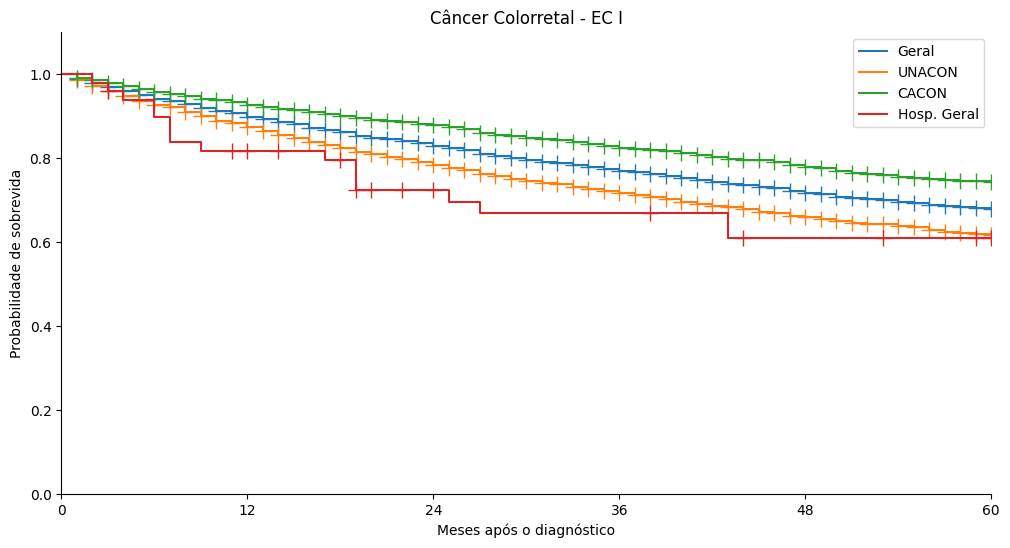

In [ ]:
data = df_ec1

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Câncer Colorretal - EC I'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Meses após o diagnóstico')
ax.set_ylabel('Probabilidade de sobrevida')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 60]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 0.0006026
    CACON com Hosp. Geral = 1.456e-09



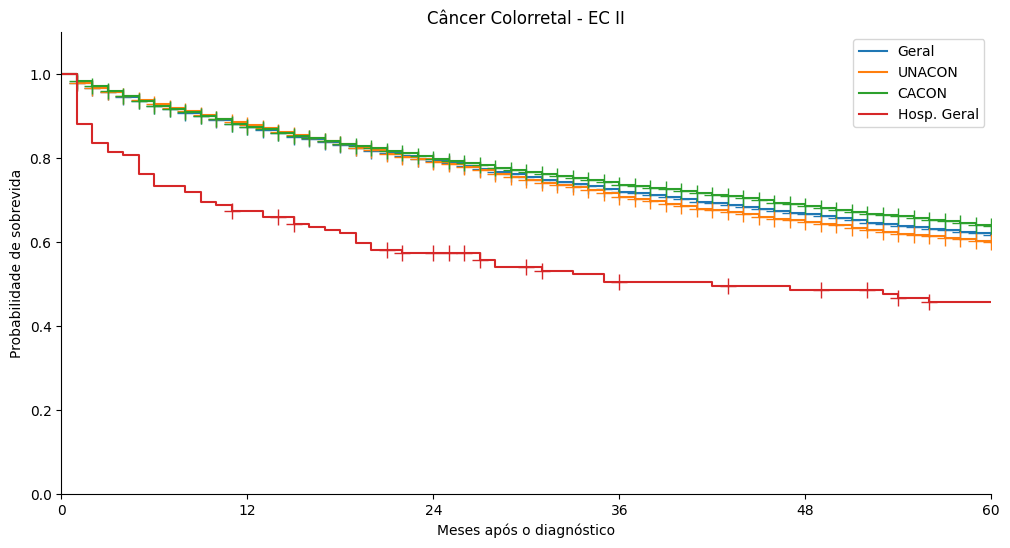

In [ ]:
data = df_ec2

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Câncer Colorretal - EC II'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Meses após o diagnóstico')
ax.set_ylabel('Probabilidade de sobrevida')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 60]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 1.954e-06
    CACON com Hosp. Geral = 5.288e-05



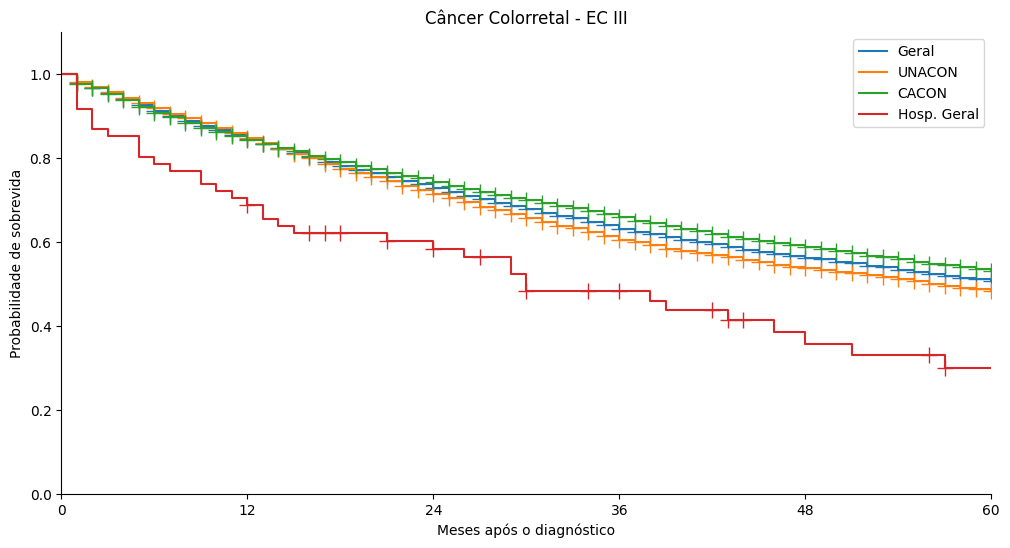

In [ ]:
data = df_ec3

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Câncer Colorretal - EC III'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Meses após o diagnóstico')
ax.set_ylabel('Probabilidade de sobrevida')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 60]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 1.448e-07
    CACON com Hosp. Geral = 0.01222



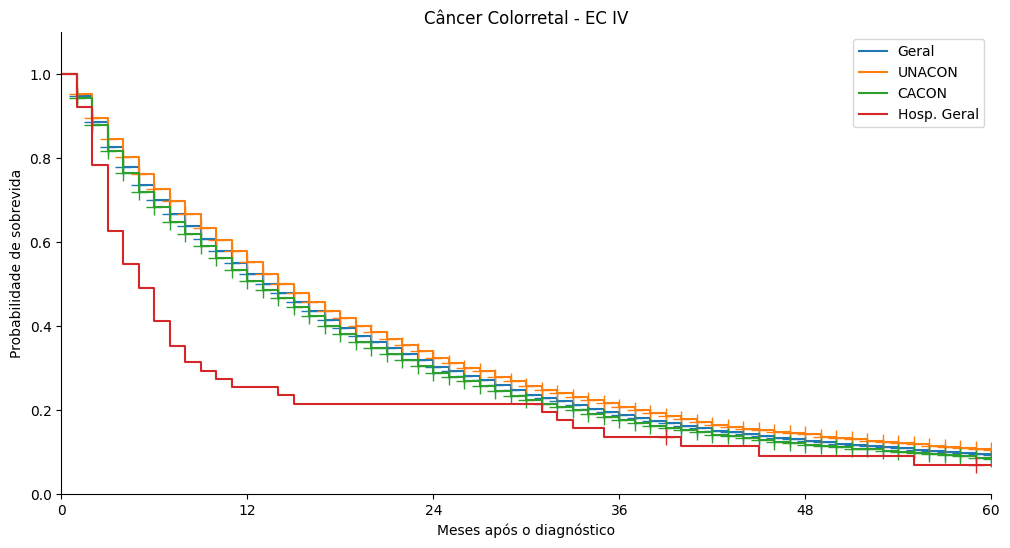

In [ ]:
data = df_ec4

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Câncer Colorretal - EC IV'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Meses após o diagnóstico')
ax.set_ylabel('Probabilidade de sobrevida')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 60]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

**DRS**

In [ ]:
df.DRS.value_counts().sort_index()

,count
DRS,
1,17977
2,1559
3,1094
4,1359
5,1195
6,2031
7,5079
8,490
9,1394


In [ ]:
results_drs = pd.DataFrame(columns=['DRS', 'Total', 'Inicial', 'Avançado',
                                    'mean', 'min', '25%', '50%', '75%', 'max'])

list_drs = np.sort(df.DRS.unique())

for n_drs in list_drs:

    df_drs = df[df.DRS == n_drs]

    n = df_drs.shape[0]
    ini = df_drs.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Inicial']
    avanc = df_drs.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Avançado']

    E = (df_drs.obito_geral == 1)
    T = df_drs.meses_diag

    kmf = KaplanMeierFitter()

    surv_info = kmf.fit(T, E).survival_function_.describe().T[['mean', 'min', '25%', '50%', '75%', 'max']].values[0]

    new = {'DRS': n_drs, 'Total': n, 'Inicial': ini, 'Avançado': avanc,
           'mean': surv_info[0], 'min': surv_info[1], '25%': surv_info[2],
           '50%': surv_info[3], '75%': surv_info[4], 'max': surv_info[5]}

    results_drs = pd.concat([results_drs, pd.DataFrame([new])], ignore_index=True)

results_drs

/tmp/ipykernel_21354/3485462167.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_drs = pd.concat([results_drs, pd.DataFrame([new])], ignore_index=True)


,DRS,Total,Inicial,Avançado,mean,min,25%,50%,75%,max
0,1,17977,0.366913,0.633087,0.602884,0.417779,0.474009,0.562075,0.703690,1.0
1,2,1559,0.406030,0.593970,0.673174,0.479396,0.535999,0.644231,0.780839,1.0
2,3,1094,0.357404,0.642596,0.624984,0.427488,0.497490,0.574073,0.740608,1.0
3,4,1359,0.454010,0.545990,0.695125,0.508517,0.567760,0.658147,0.799562,1.0
4,5,1195,0.427615,0.572385,0.645727,0.492910,0.530097,0.604024,0.738951,1.0
5,6,2031,0.448548,0.551452,0.572196,0.408422,0.451259,0.525149,0.657333,1.0
6,7,5079,0.356960,0.643040,0.660307,0.475394,0.534402,0.623827,0.765507,1.0
7,8,490,0.395918,0.604082,0.592389,0.414011,0.462470,0.554608,0.697701,1.0
8,9,1394,0.451220,0.548780,0.597948,0.417232,0.462431,0.553389,0.706028,1.0
9,10,2114,0.514664,0.485336,0.660792,0.465726,0.519631,0.615928,0.780246,1.0


In [ ]:
def plot_km_drs(df, n_drs):

    data = df[df.DRS == n_drs]

    E = (data.obito_geral == 1)
    T = data.meses_diag
    title = f'Câncer Colorretal - DRS {n_drs}'

    kmf = KaplanMeierFitter()

    fig = plt.figure(figsize=(12, 6))
    ax = plt.subplot(111)
    ax = kmf.fit(T, E, #label=f'DRS {n_drs}'
    ).plot(ax=ax, ci_show=False, show_censors=True)

    ax.set_title(title)
    ax.set_xlabel('Meses após o diagnóstico')
    ax.set_ylabel('Probabilidade de sobrevida')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(np.arange(0, 72, 12))
    plt.ylim([0, 1.1])
    plt.xlim([0, 60]);

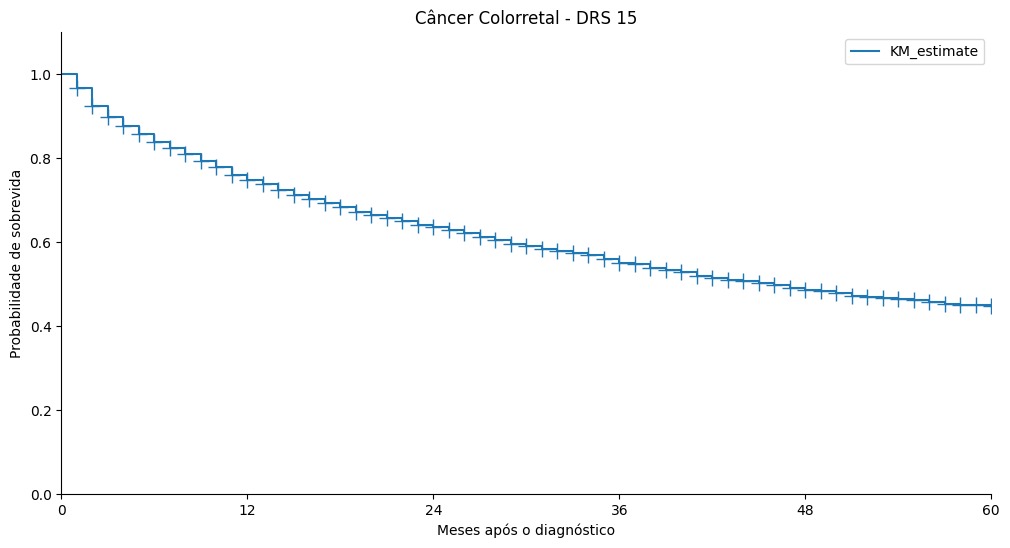

In [ ]:
plot_km_drs(df, 15)

In [ ]:
results_drs.to_csv('results_drs.csv', index=False)

**RRAS**

In [ ]:
df.RRAS.value_counts().sort_index()

,count
RRAS,
RRAS 01,2061
RRAS 02,1484
RRAS 03,299
RRAS 04,757
RRAS 05,1135
RRAS 06,12241
RRAS 07,1526
RRAS 08,1629
RRAS 09,2031


In [ ]:
results_rras = pd.DataFrame(columns=['RRAS', 'Total', 'Inicial', 'Avançado',
                                     'mean', 'min', '25%', '50%', '75%', 'max'])

list_rras = np.sort(df.RRAS.unique())

for n_rras in list_rras:

    df_rras = df[df.RRAS == n_rras]

    n = df_rras.shape[0]
    ini = df_rras.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Inicial']
    avanc = df_rras.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Avançado']

    E = (df_rras.obito_geral == 1)
    T = df_rras.meses_diag

    kmf = KaplanMeierFitter()

    surv_info = kmf.fit(T, E).survival_function_.describe().T[['mean', 'min', '25%', '50%', '75%', 'max']].values[0]

    new = {'RRAS': n_rras, 'Total': n, 'Inicial': ini, 'Avançado': avanc,
           'mean': surv_info[0], 'min': surv_info[1], '25%': surv_info[2],
           '50%': surv_info[3], '75%': surv_info[4], 'max': surv_info[5]}

    results_rras = pd.concat([results_rras, pd.DataFrame([new])], ignore_index=True)

results_rras

/tmp/ipykernel_21354/1082589463.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_rras = pd.concat([results_rras, pd.DataFrame([new])], ignore_index=True)


,RRAS,Total,Inicial,Avançado,mean,min,25%,50%,75%,max
0,RRAS 01,2061,0.398350,0.601650,0.661081,0.481341,0.543604,0.626997,0.755991,1.0
1,RRAS 02,1484,0.404987,0.595013,0.654062,0.446567,0.529771,0.633475,0.760543,1.0
2,RRAS 03,299,0.377926,0.622074,0.627245,0.426942,0.498339,0.584696,0.742852,1.0
3,RRAS 04,757,0.335535,0.664465,0.565803,0.389015,0.423114,0.508440,0.657829,1.0
4,RRAS 05,1135,0.327753,0.672247,0.594271,0.403835,0.452836,0.551241,0.714641,1.0
5,RRAS 06,12241,0.362307,0.637693,0.590509,0.406479,0.460939,0.547519,0.690782,1.0
6,RRAS 07,1526,0.445609,0.554391,0.695678,0.505665,0.564859,0.663015,0.801909,1.0
7,RRAS 08,1629,0.372007,0.627993,0.654583,0.471786,0.519165,0.617824,0.760491,1.0
8,RRAS 09,2031,0.448548,0.551452,0.572196,0.408422,0.451259,0.525149,0.657333,1.0
9,RRAS 10,1394,0.451220,0.548780,0.597948,0.417232,0.462431,0.553389,0.706028,1.0


In [ ]:
def plot_km_rras(df, n_rras):

    data = df[df.RRAS == n_rras]

    E = (data.obito_geral == 1)
    T = data.meses_diag
    title = f'Câncer Colorretal - {n_rras}'

    kmf = KaplanMeierFitter()

    fig = plt.figure(figsize=(12, 6))
    ax = plt.subplot(111)
    ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)

    ax.set_title(title)
    ax.set_xlabel('Meses após o diagnóstico')
    ax.set_ylabel('Probabilidade de sobrevida')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(np.arange(0, 72, 12))
    plt.ylim([0, 1.1])
    plt.xlim([0, 60]);

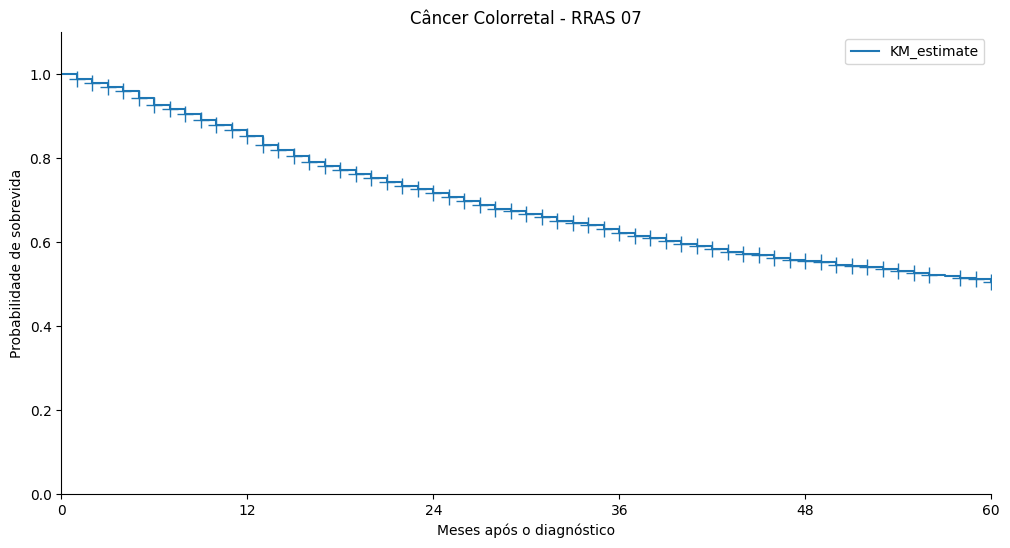

In [ ]:
plot_km_rras(df, 'RRAS 07')

In [ ]:
results_rras.to_csv('results_rras.csv', index=False)

# **Results**

### Selections made:
- Age greater than 19 years;
- State of residence in São Paulo;
- Clinical staging categorized as I, II, III, or IV (excluding in situ cases);
- Patients with microscopic confirmation;
- Patients who did not undergo bone marrow transplantation;
- Morphology 81403;
- Topography categorized as ICD-10 C18, C19, or C20.

### Initial Database size:
1233793 pacients
### Final database size:
44857 pacients


## Requirements Synchronization

In [ ]:
sync("data_analysis", ["seaborn", "plotly", "scikit-learn", "lifelines"])

[ADICIONADO] seaborn==0.13.2
[ADICIONADO] plotly==5.24.1
[ADICIONADO] scikit-learn==1.6.1
[ADICIONADO] lifelines==0.30.3

data_analysis.txt atualizado.
